In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

from set_font import set_chinese_font
custom_font_path = 'Times_SimSun.ttf'
set_chinese_font(custom_font_path)

## 数据处理

In [2]:
poi = pd.read_csv('data/上海市2020年POI.zip', encoding='utf8')
road = gpd.read_file('data/路网.shp')
city = gpd.read_file('data/研究区.shp', encoding='utf-8')

### Road

<Axes: >

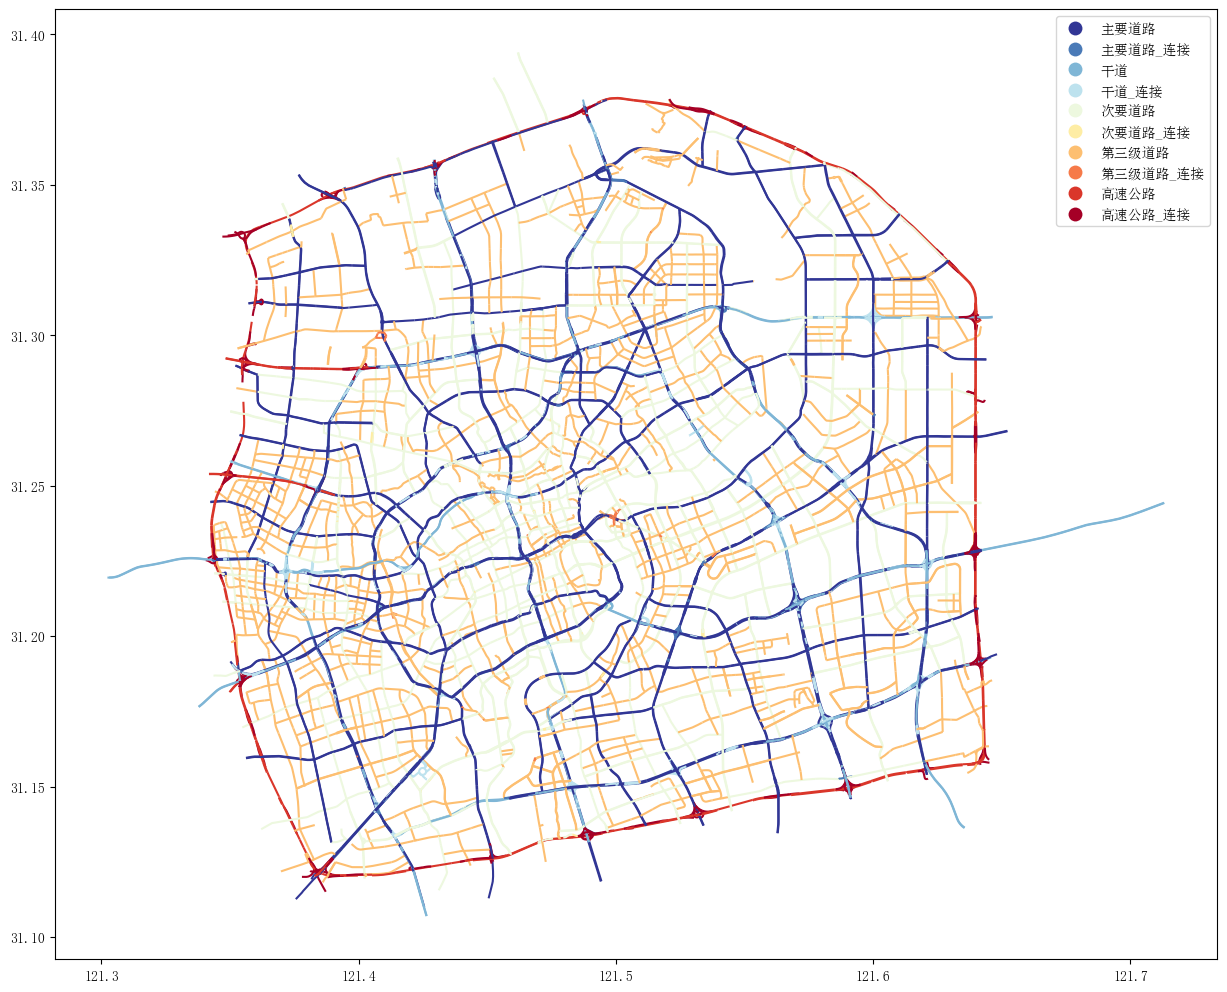

In [3]:
# 根据我们的研究选择相应等级的道路
# select_ = ['高速公路','干道','主要道路','次要道路','第三级道路']
select = ['高速公路','高速公路_连接','干道','干道_连接','主要道路','主要道路_连接','次要道路','次要道路_连接','第三级道路','第三级道路_连接']
road = road[road.fclass_cn.isin(select)].copy().reset_index(drop=True)
road.plot(column='fclass_cn', legend=True, figsize=(15,15), cmap='RdYlBu_r')

### POI

In [4]:
poi.drop(columns=['中类','小类'], inplace=True)
poi.rename(columns={'中类1':'中类','小类1':'小类'}, inplace=True)

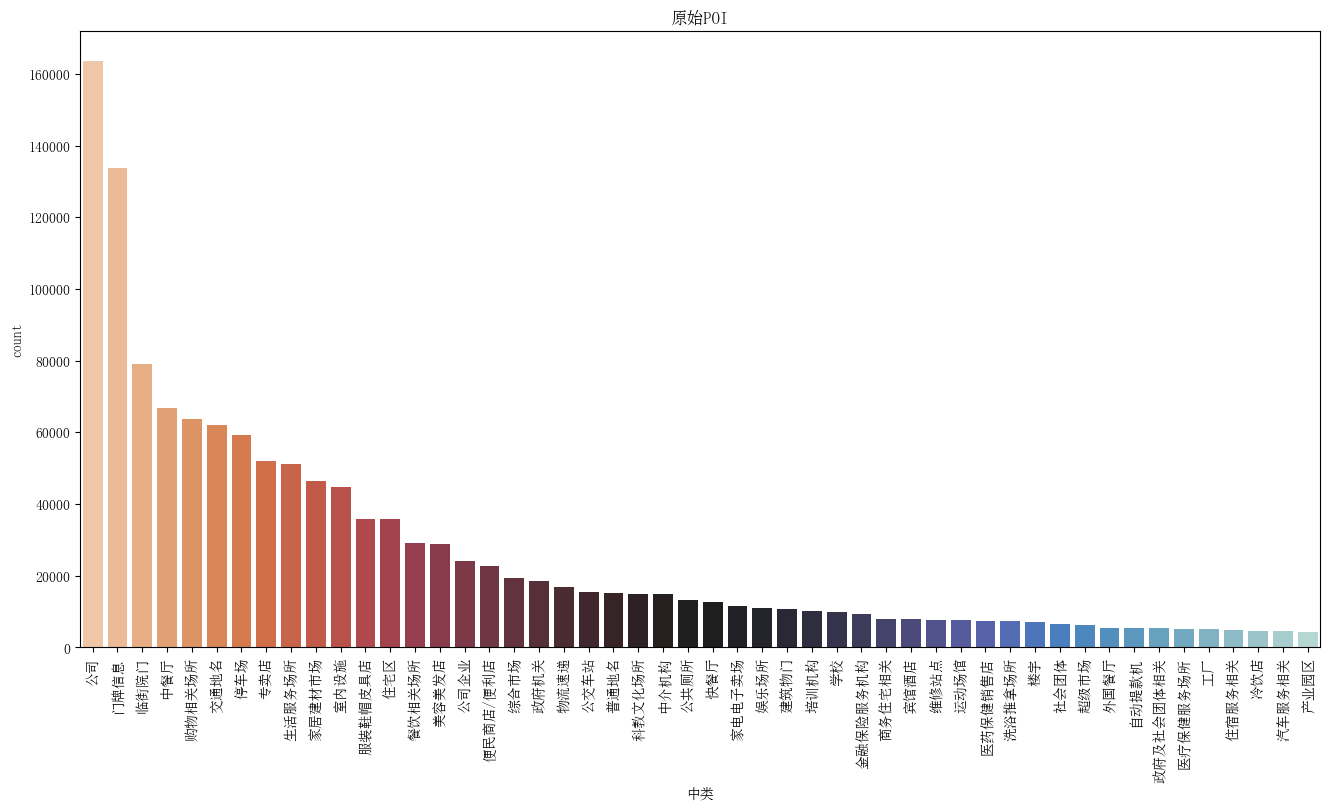

In [5]:
plt.figure(figsize=(16,8))
poi0 = poi.groupby(by='中类',as_index=False).agg({'小类':'count'}).rename(columns={'小类':'count'})
sns.barplot(x='中类', y='count', data=poi0.sort_values(by='count',ascending=False).head(50), hue='中类', palette='icefire_r')
plt.xticks(rotation=90)
plt.title('原始POI')
plt.show()

In [6]:
# 先过滤POI数据
DROP_1 = ['道路附属设施','地名地址信息','事件活动','室内设施','虚拟数据','通行设施','交通设施服务']  # 一类
DROP_2 = ['自动提款机','报刊亭']  # 二类
SAVE_2 = ['机场相关','火车站','长途汽车站']  # 二类

poi = poi[~poi['大类'].isin(DROP_1)]
poi = poi[~poi['中类'].isin(DROP_2) | poi['中类'].isin(SAVE_2)]

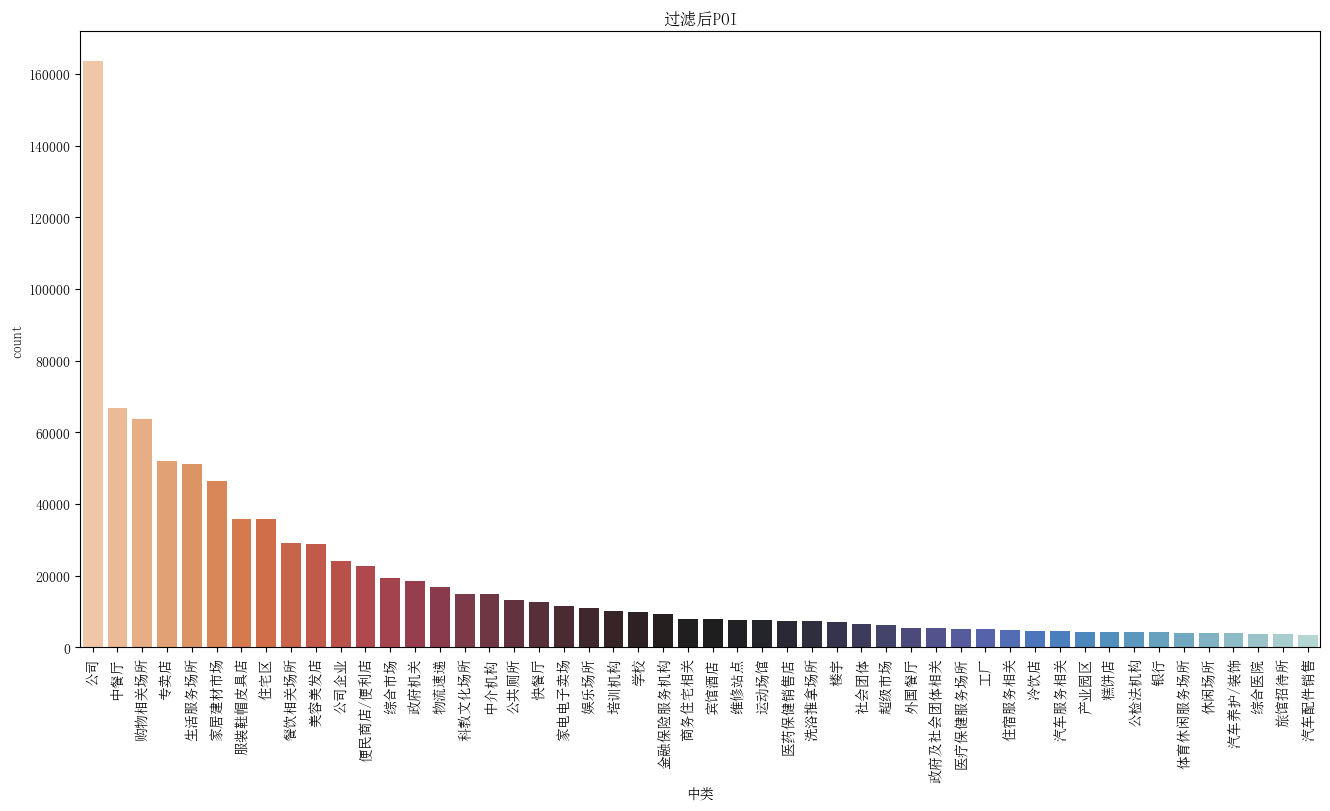

In [7]:
plt.figure(figsize=(16,8))
poi0 = poi.groupby(by='中类',as_index=False).agg({'小类':'count'}).rename(columns={'小类':'count'})
sns.barplot(x='中类', y='count', data=poi0.sort_values(by='count',ascending=False).head(50), hue='中类', palette='icefire_r')
plt.xticks(rotation=90)
plt.title('过滤后POI')
plt.show()

In [8]:
poi.reset_index(drop=True, inplace=True)
poi['poiID'] = poi.index

In [9]:
# poi转换为GeoDataFrame
poi = gpd.GeoDataFrame(poi, geometry=gpd.points_from_xy(poi['wgs84lon'], poi['wgs84lat']), crs='EPSG:4326')

In [10]:
# 提取研究区内的POI
poi = poi.clip(city)

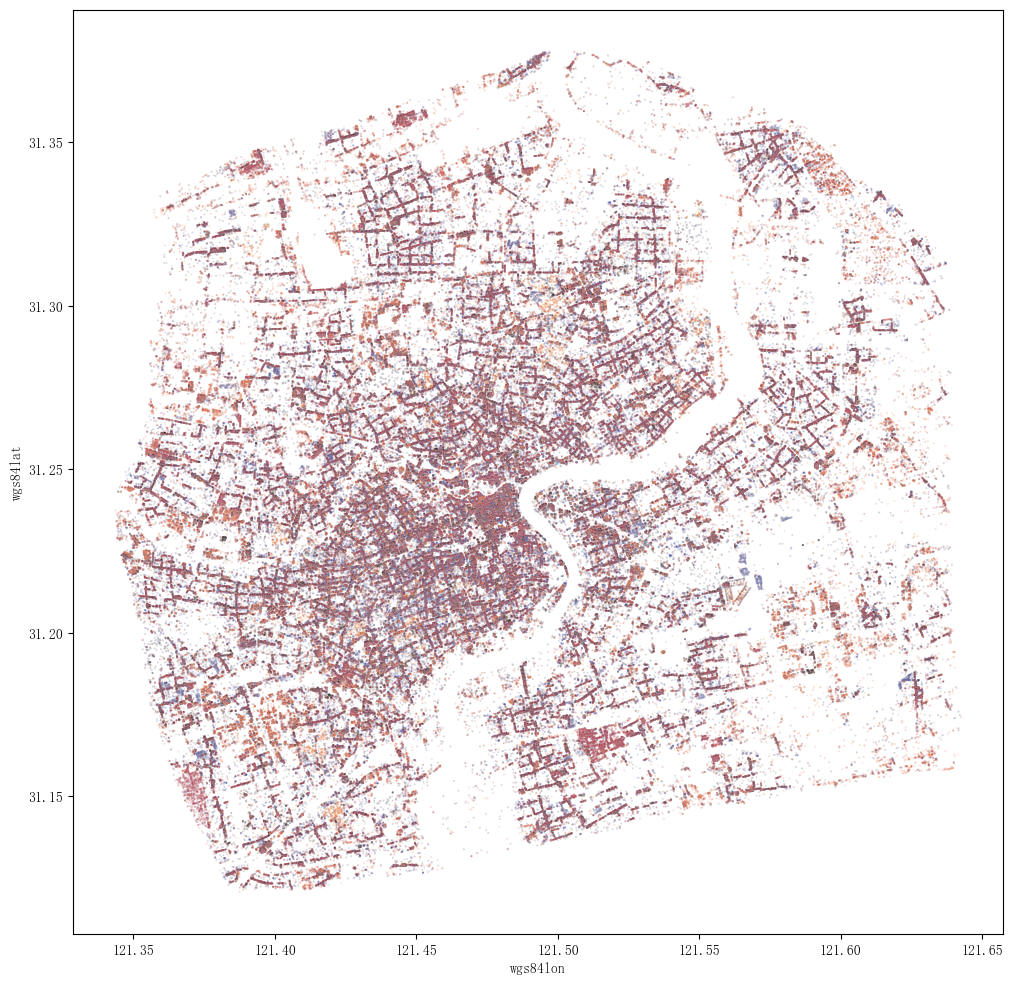

In [11]:
plt.figure(figsize=(12,12))
sns.scatterplot(x='wgs84lon', y='wgs84lat', data=poi, hue='大类', palette='icefire_r', s=2, alpha=0.2, legend=False)
plt.show()

## TAZ

In [25]:
def get_different_buffer(gdf, field, buffer_distances):
    gdf_out = gpd.GeoDataFrame()
    groups = gdf.groupby(field)
    for level, group in groups:
        if level in buffer_distances:
            # 创建指定宽度的缓冲区
            buffered = group.buffer(buffer_distances[level])
            gdf_buffer = gpd.GeoDataFrame(group[field], geometry=buffered)
            gdf_out = pd.concat([gdf_out, gdf_buffer], ignore_index=True)
    return gdf_out

In [26]:
buffer_distances = {
    '高速公路': 40, '高速公路_连接': 40,
    '干道': 40, '干道_连接': 40,
    '主要道路': 40, '主要道路_连接': 40,
    '次要道路': 20, '次要道路_连接': 20,
    '第三级道路': 10, '第三级道路_连接': 10
}
road_buffer = get_different_buffer(road.to_crs(32651), 'fclass_cn', buffer_distances)  # 转换为投影坐标系

<Axes: >

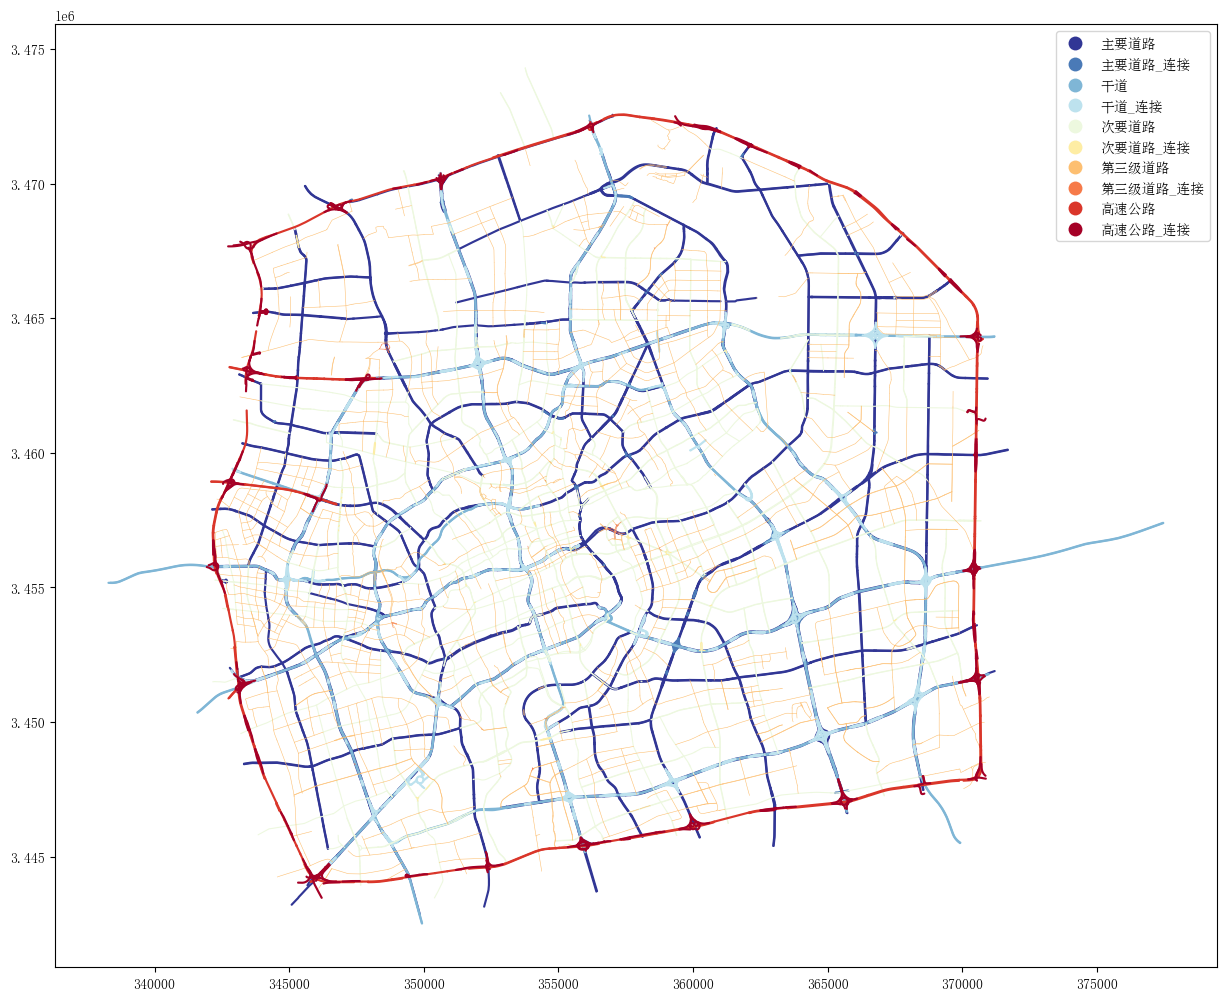

In [27]:
road_buffer.plot(column='fclass_cn', legend=True, figsize=(15,15), cmap='RdYlBu_r')

In [ ]:
import momepy as mm

enclosures = mm.enclosures(road_buffer, limit=city.to_crs(32651))  # 围合区域

<Axes: >

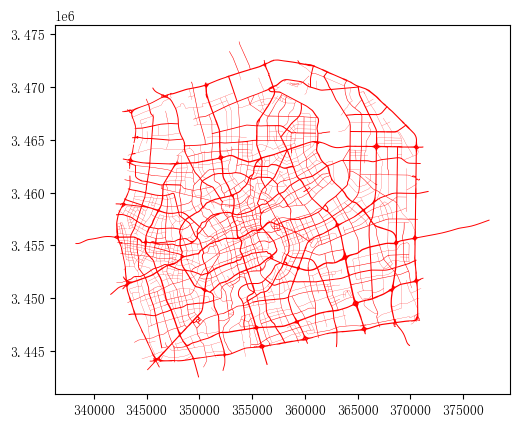

In [36]:
enclosures.head(1).plot(color='red') # 该方法获取到围合区域包含了缓冲区路网，后续需要剔除

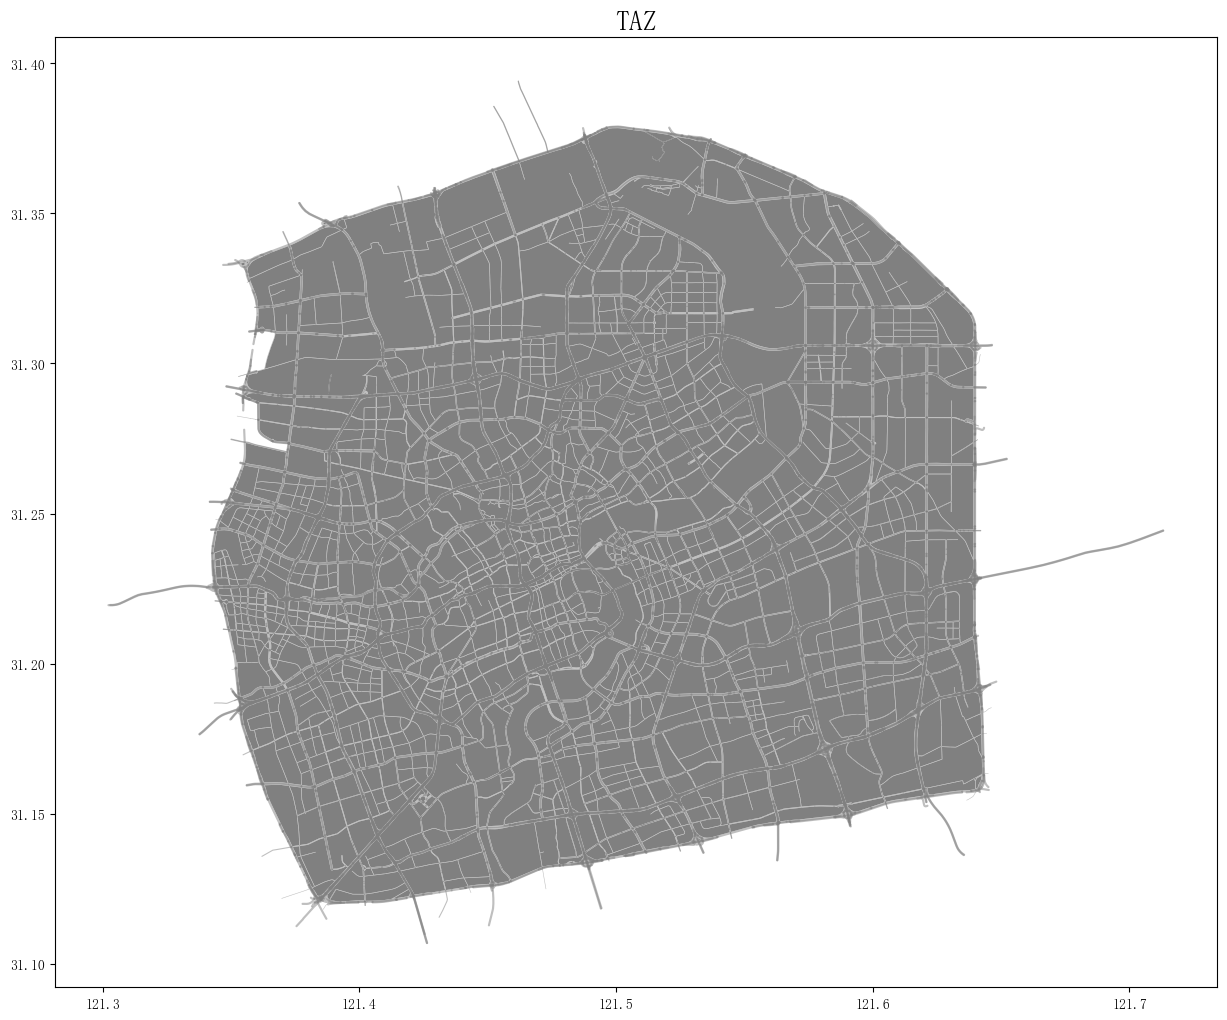

In [38]:
# 过滤路网
taz = enclosures[enclosures['eID']!=0].copy()
taz.reset_index(drop=True, inplace=True)
taz = taz.to_crs(4326)

ax = taz.plot(figsize=(15,15), color='grey')
road_buffer.to_crs(4326).plot(ax=ax ,color='grey', alpha=0.5)
plt.title('TAZ', fontsize=20)
plt.show()

## 地理语料库

In [24]:
# 空间连接
poi_taz = gpd.sjoin(poi, taz, predicate='within').dropna(subset=['eID'])
poi_taz

,name,address,pname,cityname,adname,wgs84lon,wgs84lat,大类,中类,小类,poiID,geometry,index_right,eID
127348,上海罗阳制冷成套设备有限公司,梅陇镇景福路18号,上海市,上海市,闵行区,121.406138,31.121398,公司企业,公司,公司,127348,POINT (121.40614 31.12140),253,254
127339,上海森诺贸易有限公司,梅陇镇景福路18号,上海市,上海市,闵行区,121.406138,31.121398,公司企业,公司,商业贸易,127339,POINT (121.40614 31.12140),253,254
552487,协和罗阳幼儿园,梅陇镇罗锦路888号8支弄22号,上海市,上海市,闵行区,121.392750,31.121456,科教文化服务,科教文化场所,科教文化场所,552487,POINT (121.39275 31.12146),257,258
552440,联报万象梅陇站,莘朱路1258-1号楼附近,上海市,上海市,闵行区,121.410619,31.121467,科教文化服务,科教文化场所,科教文化场所,552440,POINT (121.41062 31.12147),253,254
653067,回收香烟,景福路西50米,上海市,上海市,闵行区,121.405548,31.121486,购物服务,专卖店,专营店,653067,POINT (121.40555 31.12149),253,254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
346860,工商注册大厅,淞滨路28号1楼,上海市,上海市,宝山区,121.495455,31.377491,政府机构及社会团体,政府及社会团体相关,政府及社会团体相关,346860,POINT (121.49546 31.37749),1639,1640
389711,小张汽修汽配,崇景路与G1501上海绕城高速交叉口南100米,上海市,上海市,浦东新区,121.506782,31.377585,汽车维修,汽车维修,汽车维修,389711,POINT (121.50678 31.37758),1639,1640
138739,创元七堆场,江东路1号,上海市,上海市,浦东新区,121.505729,31.377666,公司企业,公司,公司,138739,POINT (121.50573 31.37767),1639,1640
465641,上海宏兴物流有限公司,江东路1号3号门,上海市,上海市,浦东新区,121.505942,31.377696,生活服务,物流速递,物流速递,465641,POINT (121.50594 31.37770),1639,1640


In [25]:
# 邻近分析
poi_taz1 = poi[~poi['poiID'].isin(poi_taz['poiID'])].copy()
poi_taz1 = poi_taz1.sjoin_nearest(taz)
poi_taz = pd.concat([poi_taz,poi_taz1]).reset_index(drop=True)

d:\Anaconda3\envs\py311\Lib\site-packages\geopandas\array.py:365: UserWarning: Geometry is in a geographic CRS. Results from 'sjoin_nearest' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  warnings.warn(


In [26]:
poi_taz

,name,address,pname,cityname,adname,wgs84lon,wgs84lat,大类,中类,小类,poiID,geometry,index_right,eID
0,上海罗阳制冷成套设备有限公司,梅陇镇景福路18号,上海市,上海市,闵行区,121.406138,31.121398,公司企业,公司,公司,127348,POINT (121.40614 31.12140),253,254
1,上海森诺贸易有限公司,梅陇镇景福路18号,上海市,上海市,闵行区,121.406138,31.121398,公司企业,公司,商业贸易,127339,POINT (121.40614 31.12140),253,254
2,协和罗阳幼儿园,梅陇镇罗锦路888号8支弄22号,上海市,上海市,闵行区,121.392750,31.121456,科教文化服务,科教文化场所,科教文化场所,552487,POINT (121.39275 31.12146),257,258
3,联报万象梅陇站,莘朱路1258-1号楼附近,上海市,上海市,闵行区,121.410619,31.121467,科教文化服务,科教文化场所,科教文化场所,552440,POINT (121.41062 31.12147),253,254
4,回收香烟,景福路西50米,上海市,上海市,闵行区,121.405548,31.121486,购物服务,专卖店,专营店,653067,POINT (121.40555 31.12149),253,254
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
530236,秀桥旅馆(牡丹江路),淞滨路103-1号,上海市,上海市,宝山区,121.494812,31.377365,住宿服务,旅馆招待所,旅馆招待所,6414,POINT (121.49481 31.37737),1639,1640
530237,中华联合财产保险公司上海市(宝山支公司),牡丹江路50号附近,上海市,上海市,宝山区,121.494711,31.377454,金融保险服务,保险公司,保险公司,862368,POINT (121.49471 31.37745),1639,1640
530238,宝山区珠义平杂货店,牡丹江路52号附近,上海市,上海市,宝山区,121.494803,31.377545,购物服务,专卖店,专营店,722385,POINT (121.49480 31.37755),1639,1640
530239,百岁山连锁超市,牡丹江路52号,上海市,上海市,宝山区,121.494718,31.377585,购物服务,购物相关场所,购物相关场所,722375,POINT (121.49472 31.37758),1639,1640


In [28]:
import numpy as np
from tqdm import tqdm

def get_distance_matrix(points):
    """
    使用矩阵计算点之间的欧氏距离
    输入格式为 df[x,y]
    """
    n = points.shape[0]  # 获取数据长度
    tiled_points = np.tile(points, (n, 1, 1))  # 将数组points沿其第一个轴以n倍的方式进行复制拼接，而在其余轴上则保持原样: n*n*2
    # 原数组tiled_points的第二个轴（行）变为新数组的第一个轴（列）；
    # 原数组tiled_points的第一个轴（列）变为新数组的第二个轴（行）；
    # 原数组tiled_points的第三个轴保持不变，仍然是新数组的第三个轴。
    # n*n*2
    tiled_points_T = np.transpose(tiled_points, axes=(1, 0, 2))
    distance_matrix = np.linalg.norm(tiled_points - tiled_points_T, axis=2)
    return distance_matrix

# 左到右以此插入序列，可以得到的序列组合
def get_insert_sequences(node, nodes_list):
    insert_sequences = []
    for i in range(len(nodes_list) + 1):
        sequence = nodes_list.copy()  # 复制新的节点列表，避免在原列表上进行修改
        sequence.insert(i, node)  # 在指定位置插入节点
        insert_sequences.append(sequence)
    return insert_sequences

# 贪婪算法获取最短路径
def get_shortest_sequence(df):
    matrix = get_distance_matrix(df)
    distance_df = pd.DataFrame(data=matrix, index=df.index, columns=df.index)
    # 找到距离最大的两个点
    max_points = np.unravel_index(np.argmax(matrix), matrix.shape)

    # 初始化最短路径长度为最大值
    start_node, end_node = max_points
    shortest_length_nodes = [start_node, end_node]
    nodes = [node for node in distance_df.index if node != start_node and node != end_node]
    shortest_sequence = shortest_length_nodes.copy()
    
    while len(nodes) > 0:
        # 选择插入节点
        node = np.random.choice(nodes)
        nodes.remove(node)
        # 生成插入序列
        insert_sequences = get_insert_sequences(node, shortest_sequence)
        # 初始化参数
        shortest_length = np.inf
        # 寻找最短路径
        for sequence in insert_sequences:
            sequence_length = 0
            for j in range(len(sequence) - 1):
                # 使用距离矩阵中的距离值
                sequence_length += matrix[sequence[j]][sequence[j+1]]
            
            if sequence_length < shortest_length:
                shortest_length = sequence_length
                shortest_sequence = sequence
                
    return shortest_sequence

In [32]:
run = False
if run:
    eIDs = []
    poi_documents = []
    
    for eID in tqdm(poi_taz.eID.unique(), desc='get shortest length'):
        group = poi_taz.query(f'eID=={eID}').copy().reset_index(drop=True)
        # 放大坐标，避免小数位数太多造成精度问题，导致结果不一致
        group['wgs84lon'] = group['wgs84lon'] * 1000
        group['wgs84lat'] = group['wgs84lon'] * 1000
    
        eIDs.append(eID)
        poi_documents.append(list(group.loc[get_shortest_sequence(group[['wgs84lon','wgs84lat']])]['中类']))

    Docs = pd.DataFrame(data={'eID':eIDs,'Doc':poi_documents})
    Docs.to_csv('data/地理语料库_taz.csv', index=False)
else:
    print('Flase run')
    Docs = pd.read_csv('data/地理语料库_taz.csv')

Flase run


In [33]:
import ast

Docs['Doc'] = Docs['Doc'].apply(lambda x: ast.literal_eval(x))
Docs

,eID,Doc
0,254.0,"[公司, 公司企业, 公司, 住宅区, 住宅区, 休闲场所, 科教文化场所, 政府及社会团体..."
1,258.0,"[体育休闲服务场所, 科教文化场所, 运动场馆, 综合市场, 专卖店, 宾馆酒店, 服装鞋帽..."
2,239.0,"[公共厕所, 旅行社, 旅行社, 公司, 生活服务场所, 便民商店/便利店, 糕饼店, 公司..."
3,255.0,"[汽车维修, 服装鞋帽皮具店, 购物相关场所, 家居建材市场, 住宅区, 科教文化场所, 专..."
4,253.0,"[公检法机构, 公检法机构, 公检法机构, 工商税务机构, 公检法机构, 商务住宅相关, 住..."
...,...,...
1553,977.0,"[公园广场, 公园广场]"
1554,1515.0,"[公共厕所, 购物相关场所]"
1555,1439.0,"[产业园区, 公司, 公司, 公司企业, 汽车维修, 汽车养护/装饰, 公司企业, 金融保险..."
1556,1628.0,"[公共厕所, 公共厕所]"


## Word2Vec

In [35]:
from gensim.models import Word2Vec 

In [36]:
# sentences=[["a","b"],["b","c"] ... ]
poi_corpus = [Doc for Doc in Docs.Doc]  # 每一行为一个文档

In [37]:
# 定义Word2Vec模型参数，使用Skip-Gram模型
model_params = {
    'vector_size': 200,  # 词向量维度
    'window': 5,  # 窗口大小
    'min_count': 1,  # 忽略出现次数少于1次的单词
    'workers': 4,  # 使用多线程
    'sg': 0,  # 1:Skip-Gram模型
}
model = Word2Vec(poi_corpus, **model_params)

In [38]:
model.build_vocab(poi_corpus)  # 构建词汇表
model.train(poi_corpus, total_examples=model.corpus_count, epochs=100)  # 训练模型

(16526861, 53026200)

In [39]:
# 获取所有单词列表
all_words = model.wv.index_to_key
print("前10个单词:", all_words[:10])
print("总单词数:", len(all_words))

前10个单词: ['公司', '购物相关场所', '中餐厅', '专卖店', '生活服务场所', '服装鞋帽皮具店', '家居建材市场', '住宅区', '餐饮相关场所', '美容美发店']
总单词数: 187


In [40]:
# 获取指定单词向量表示
model.wv['公司']

array([ 1.0616248e+00, -1.3078198e-01,  6.0508728e-01,  2.8422987e-02,
       -5.0674987e-01,  1.0790797e+00, -1.4021548e+00,  8.1702691e-01,
        1.5844860e+00,  9.1896510e-01, -7.1754390e-01,  7.1152788e-01,
        1.9274478e-01, -1.0155955e-01, -9.1875160e-01, -6.6535509e-01,
        1.8325515e-02, -3.1693587e-01, -1.0371282e+00, -4.8920134e-01,
       -2.2441986e-01,  1.4755049e-01,  3.1478128e-01, -1.7319672e-01,
        3.0604449e-01, -9.6195853e-01, -7.0828557e-01,  6.7742288e-01,
        6.4446270e-01,  1.3347825e+00, -1.0446919e+00,  9.3030226e-01,
       -1.0485626e-01,  3.6880964e-01, -8.2851124e-01,  6.2821776e-02,
       -7.7038240e-01,  1.4657868e-01, -6.2524122e-01, -2.5821457e+00,
       -2.1156912e+00,  2.0181410e+00,  5.6077999e-01,  1.6714139e-02,
       -1.7981073e+00,  1.7928925e-01,  4.2618451e-01, -6.2035155e-01,
       -1.2369794e+00,  1.2317791e+00,  1.3610116e+00, -1.8576616e+00,
        4.0252540e-01,  8.1464037e-02,  1.4806193e+00,  2.2372499e-01,
      

In [41]:
# 查找与给定单词最相似的单词
model.wv.most_similar('公司', topn=10)

[('公司企业', 0.7548952102661133),
 ('传媒机构', 0.7331078052520752),
 ('楼宇', 0.7189664840698242),
 ('事务所', 0.6930481791496277),
 ('金融保险服务机构', 0.684633731842041),
 ('保险公司', 0.6743248105049133),
 ('产业园区', 0.6567535400390625),
 ('知名企业', 0.6522383689880371),
 ('物流速递', 0.5702421069145203),
 ('外国机构', 0.4638840854167938)]

In [42]:
# 计算两个文档之间的相似度
i, j = 0, 4
x = Docs.loc[i,'Doc']
y = Docs.loc[j,'Doc']
print('文档：\n',x)
print('---------------------------------------')
print('文档：\n',y)
print('指定两个文档之间的相似度',model.wv.n_similarity(x,y))

文档：
 ['公司', '公司企业', '公司', '住宅区', '住宅区', '休闲场所', '科教文化场所', '政府及社会团体相关', '政府机关', '商务住宅相关', '政府机关', '购物相关场所', '银行', '邮局', '维修站点', '综合市场', '旅馆招待所', '住宅区', '生活服务场所', '综合市场', '彩票彩券销售点', '超级市场', '中餐厅', '美容美发店', '中餐厅', '餐饮相关场所', '专卖店', '中餐厅', '中餐厅', '中餐厅', '餐饮相关场所', '洗衣店', '中餐厅', '便民商店/便利店', '公检法机构', '综合市场', '综合市场', '专卖店', '购物相关场所', '公司', '中餐厅', '餐饮相关场所', '餐饮相关场所', '购物相关场所', '中餐厅', '综合市场', '购物相关场所', '政府机关', '冷饮店', '购物相关场所', '购物相关场所', '购物相关场所', '娱乐场所', '公共厕所', '楼宇', '政府机关', '公司', '公司', '美容美发店', '休闲场所', '政府机关', '快餐厅', '住宅区', '生活服务场所', '学校', '运动场馆', '购物相关场所', '公司', '充电站', '购物相关场所', '中餐厅', '购物相关场所', '公司企业', '公司企业', '公司', '生活服务场所', '公司', '公司企业', '公司', '公司企业', '公司', '公司', '公司', '公司', '公司企业', '公司', '公司', '专卖店', '餐饮相关场所', '公司', '传媒机构', '公司', '购物相关场所', '公司', '公司', '公司', '产业园区', '科教文化场所', '科教文化场所', '公司', '生活服务场所', '工厂', '公司', '服装鞋帽皮具店', '工厂', '公司', '服装鞋帽皮具店', '医疗保健服务场所', '洗浴推拿场所', '公司', '公司', '公司', '充电站', '住宅区', '家居建材市场', '公司', '汽车养护/装饰', '公司', '公司企业', '公司', '汽车服务相关', '生活服务场所', '公司', '汽车维修', '公司企业', '汽车

## TAZs向量

In [43]:
from sklearn.preprocessing import normalize

# 定义函数计算平均文档向量
def calculate_doc_mean_vector(model, doc):
    # 获取文档中每个单词的向量
    word_vectors = [model.wv[word] for word in doc if word in model.wv]
    if not word_vectors:
        # 如果文档中的所有单词都不在模型中，返回 None 或其他默认值
        return None
    # 计算单词向量的平均值作为文档向量
    doc_vector = np.mean(word_vectors, axis=0)
    return doc_vector

In [44]:
# 计算每个文档的平均向量
doc_vectors = [calculate_doc_mean_vector(model, doc) for doc in Docs.Doc]
doc_vectors = normalize(doc_vectors, norm='l2')

taz_embeddings = pd.DataFrame(doc_vectors, columns=[f'vector_{i+1}' for i in range(model.vector_size)])
taz_embeddings['eID'] = Docs['eID']

## 聚类分析

In [45]:
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

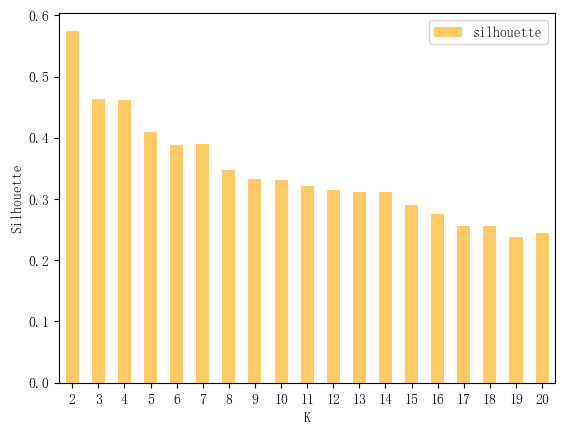

In [46]:
# 计算余弦相似度
cosine_sim = cosine_similarity(taz_embeddings.drop(columns='eID').values)
# cosine_sim = taz_embeddings.drop(columns='eID').values

# 设置参数
# 聚类分析
max_clusters = 20
ks = []
silhouettes = []
for i in range(2, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, random_state=42)
    cluster_labels = kmeans.fit_predict(cosine_sim)
    silhouette = silhouette_score(cosine_sim, cluster_labels)
    ks.append(i)
    silhouettes.append(silhouette)

df_silhouette = pd.DataFrame(data={'silhouette':silhouettes,'k':ks})
df_silhouette.plot(x='k', y='silhouette', kind='bar', color='orange', alpha=0.6)
plt.xticks(rotation=0)
plt.ylabel('Silhouette')
plt.xlabel('K')
plt.show()

## 连接到空间位置

In [47]:
for k in range(2,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(cosine_sim)
    Docs[f'k_{k}'] = cluster_labels
    Docs[f'k_{k}'] = Docs[f'k_{k}'].apply(lambda x: 'cluster '+str(x+1))
    print(Docs[f'k_{k}'].value_counts())

k_2
cluster 2    812
cluster 1    746
Name: count, dtype: int64
k_3
cluster 1    612
cluster 2    587
cluster 3    359
Name: count, dtype: int64
k_4
cluster 1    587
cluster 2    552
cluster 3    224
cluster 4    195
Name: count, dtype: int64
k_5
cluster 1    552
cluster 2    501
cluster 3    212
cluster 5    175
cluster 4    118
Name: count, dtype: int64
k_6
cluster 1    502
cluster 6    392
cluster 3    199
cluster 2    191
cluster 5    167
cluster 4    107
Name: count, dtype: int64
k_7
cluster 1    476
cluster 6    392
cluster 3    167
cluster 5    147
cluster 7    135
cluster 2    123
cluster 4    118
Name: count, dtype: int64
k_8
cluster 1    474
cluster 7    332
cluster 6    169
cluster 4    139
cluster 5    135
cluster 8    119
cluster 3     99
cluster 2     91
Name: count, dtype: int64
k_9
cluster 1    445
cluster 7    265
cluster 2    161
cluster 9    147
cluster 5    131
cluster 8    128
cluster 3    112
cluster 4     97
cluster 6     72
Name: count, dtype: int64


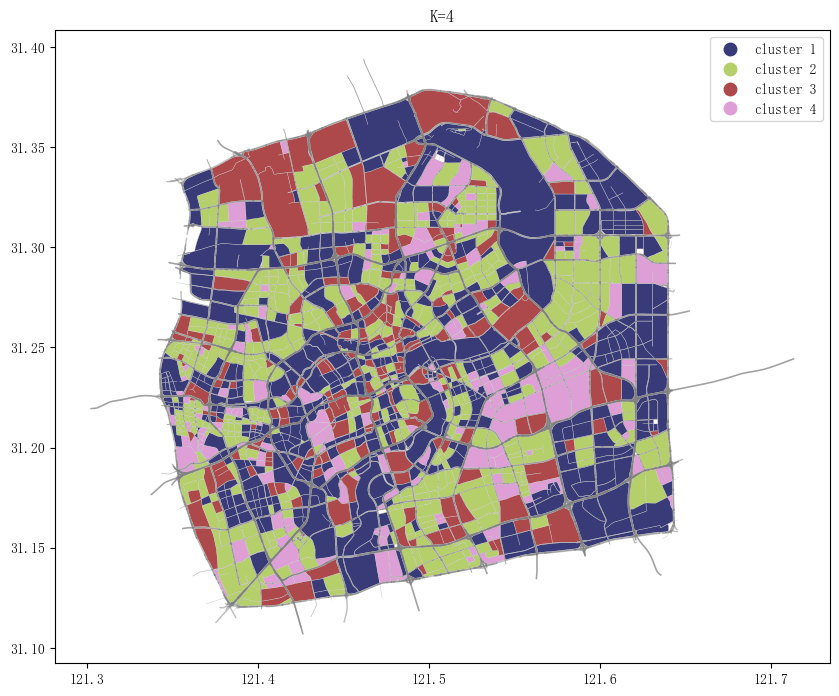

In [48]:
k = 4
ax = taz.merge(Docs[['eID',f'k_{k}']],on='eID',how='left').plot(column=f'k_{k}', figsize=(10,10), cmap='tab20b', legend=True)
road_buffer.to_crs(4326).plot(ax=ax ,color='grey', alpha=0.5)
plt.title(f'K={k}')
plt.show()

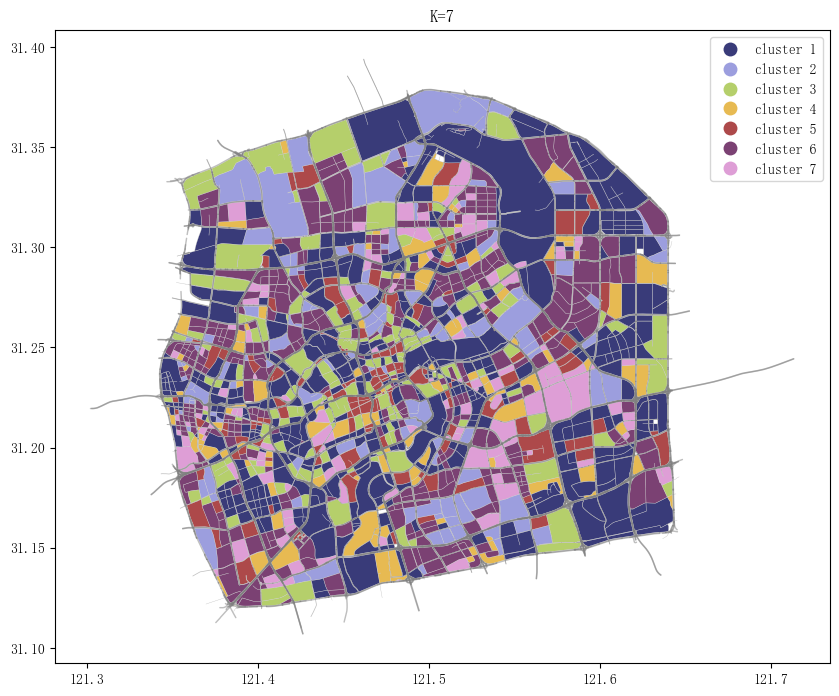

In [50]:
k = 7
ax = taz.merge(Docs[['eID',f'k_{k}']],on='eID',how='left').plot(column=f'k_{k}', figsize=(10,10), cmap='tab20b', legend=True)
road_buffer.to_crs(4326).plot(ax=ax ,color='grey', alpha=0.5)
plt.title(f'K={k}')
plt.show()

## 类内分析

### k=4

In [51]:
k = 4
df_k = poi_taz.merge(Docs[['eID',f'k_{k}']], on='eID', how='left').groupby([f'k_{k}','大类']).size().reset_index(name='count')  # 分组求和：k-类别
df_k = df_k.merge(df_k.groupby(f'k_{k}')['count'].sum().reset_index(), on=f'k_{k}', suffixes=('', '_sum'))  # k：组内和
df_k['percentage'] = (df_k['count'] / df_k['count_sum']) * 100 # 各组内得类别百分比
df_pivot = pd.pivot_table(df_k, index=f'k_{k}', columns='大类', values='percentage')  # 透视图

styled_df_pivot = df_pivot.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}%")
styled_df_pivot

大类,住宿服务,体育休闲服务,公共设施,公司企业,医疗保健服务,商务住宅,摩托车服务,政府机构及社会团体,汽车服务,汽车维修,汽车销售,生活服务,科教文化服务,购物服务,金融保险服务,风景名胜,餐饮服务
k_4,,,,,,,,,,,,,,,,,
cluster 1,1.63%,2.99%,1.16%,31.75%,1.83%,6.00%,0.05%,3.76%,1.17%,0.38%,0.29%,12.94%,5.69%,16.24%,3.29%,0.43%,10.41%
cluster 2,1.54%,3.08%,1.47%,5.92%,2.84%,5.97%,0.13%,3.60%,1.06%,0.35%,0.09%,16.95%,4.04%,35.08%,1.23%,0.37%,16.28%
cluster 3,1.71%,2.77%,1.60%,15.05%,2.04%,5.19%,0.10%,3.08%,1.44%,0.47%,0.21%,13.30%,4.19%,32.62%,1.72%,0.51%,13.99%
cluster 4,2.51%,4.38%,2.34%,9.08%,5.61%,11.16%,0.09%,7.69%,1.44%,0.39%,0.17%,14.06%,12.87%,15.99%,1.20%,1.38%,9.65%


In [52]:
# 取反
df_k = poi_taz.merge(Docs[['eID',f'k_{k}']], on='eID', how='left').groupby(['大类',f'k_{k}']).size().reset_index(name='count')
df_k = df_k.merge(df_k.groupby('大类')['count'].sum().reset_index(), on='大类', suffixes=('', '_sum'))
df_k['percentage'] = (df_k['count'] / df_k['count_sum']) * 100
df_pivot = pd.pivot_table(df_k, index=f'k_{k}', columns='大类', values='percentage')

styled_df_pivot = df_pivot.style.background_gradient(cmap='coolwarm', axis=0).format("{:.2f}%")
styled_df_pivot

大类,住宿服务,体育休闲服务,公共设施,公司企业,医疗保健服务,商务住宅,摩托车服务,政府机构及社会团体,汽车服务,汽车维修,汽车销售,生活服务,科教文化服务,购物服务,金融保险服务,风景名胜,餐饮服务
k_4,,,,,,,,,,,,,,,,,
cluster 1,35.12%,35.21%,29.01%,65.28%,26.85%,35.38%,20.28%,35.87%,34.90%,34.64%,54.43%,31.91%,39.73%,21.74%,56.72%,32.31%,28.04%
cluster 2,33.45%,36.48%,36.98%,12.27%,42.05%,35.50%,49.20%,34.65%,31.65%,32.61%,16.34%,42.11%,28.46%,47.30%,21.38%,28.16%,44.15%
cluster 3,23.53%,20.78%,25.48%,19.73%,19.08%,19.50%,25.30%,18.76%,27.21%,27.56%,24.61%,20.91%,18.67%,27.83%,18.87%,24.37%,24.01%
cluster 4,7.90%,7.53%,8.53%,2.73%,12.02%,9.62%,5.22%,10.73%,6.24%,5.19%,4.63%,5.06%,13.14%,3.13%,3.03%,15.17%,3.80%


### k=7

In [53]:
k = 7
df_k = poi_taz.merge(Docs[['eID',f'k_{k}']], on='eID', how='left').groupby([f'k_{k}','大类']).size().reset_index(name='count')  # 分组求和：k-类别
df_k = df_k.merge(df_k.groupby(f'k_{k}')['count'].sum().reset_index(), on=f'k_{k}', suffixes=('', '_sum'))  # k：组内和
df_k['percentage'] = (df_k['count'] / df_k['count_sum']) * 100 # 各组内得类别百分比
df_pivot = pd.pivot_table(df_k, index=f'k_{k}', columns='大类', values='percentage')  # 透视图

styled_df_pivot = df_pivot.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}%")
styled_df_pivot

大类,住宿服务,体育休闲服务,公共设施,公司企业,医疗保健服务,商务住宅,摩托车服务,政府机构及社会团体,汽车服务,汽车维修,汽车销售,生活服务,科教文化服务,购物服务,金融保险服务,风景名胜,餐饮服务
k_7,,,,,,,,,,,,,,,,,
cluster 1,1.55%,2.86%,1.07%,34.83%,1.66%,6.05%,0.04%,3.78%,1.19%,0.38%,0.29%,12.72%,5.79%,14.33%,3.57%,0.44%,9.45%
cluster 2,1.44%,2.35%,1.14%,12.80%,2.45%,5.43%,0.18%,3.43%,1.96%,0.76%,0.25%,14.38%,3.47%,38.03%,1.13%,0.27%,10.53%
cluster 3,1.80%,3.05%,1.43%,19.90%,2.20%,5.60%,0.10%,3.30%,1.08%,0.36%,0.22%,14.03%,4.62%,25.44%,2.13%,0.41%,14.33%
cluster 4,2.93%,4.66%,1.97%,13.15%,3.67%,9.47%,0.10%,6.75%,2.28%,0.42%,0.35%,12.63%,14.53%,15.37%,1.33%,1.34%,9.05%
cluster 5,1.74%,3.31%,2.65%,8.73%,1.61%,3.98%,0.03%,2.05%,0.54%,0.10%,0.07%,11.28%,4.43%,38.68%,1.73%,0.61%,18.45%
cluster 6,1.49%,3.02%,1.07%,5.10%,3.20%,6.47%,0.15%,4.15%,1.17%,0.39%,0.08%,19.21%,3.84%,32.56%,1.24%,0.36%,16.50%
cluster 7,2.19%,4.34%,2.29%,7.16%,6.41%,12.61%,0.05%,7.67%,1.28%,0.37%,0.19%,15.10%,9.96%,17.52%,1.11%,1.13%,10.62%


In [54]:
# 取反
df_k = poi_taz.merge(Docs[['eID',f'k_{k}']], on='eID', how='left').groupby(['大类',f'k_{k}']).size().reset_index(name='count')
df_k = df_k.merge(df_k.groupby('大类')['count'].sum().reset_index(), on='大类', suffixes=('', '_sum'))
df_k['percentage'] = (df_k['count'] / df_k['count_sum']) * 100
df_pivot = pd.pivot_table(df_k, index=f'k_{k}', columns='大类', values='percentage')

styled_df_pivot = df_pivot.style.background_gradient(cmap='coolwarm', axis=0).format("{:.2f}%")
styled_df_pivot

大类,住宿服务,体育休闲服务,公共设施,公司企业,医疗保健服务,商务住宅,摩托车服务,政府机构及社会团体,汽车服务,汽车维修,汽车销售,生活服务,科教文化服务,购物服务,金融保险服务,风景名胜,餐饮服务
k_7,,,,,,,,,,,,,,,,,
cluster 1,25.89%,25.96%,20.62%,55.30%,18.81%,27.56%,10.64%,27.88%,27.28%,27.37%,41.44%,24.23%,31.24%,14.81%,47.51%,25.71%,19.64%
cluster 2,10.26%,9.11%,9.41%,8.68%,11.85%,10.56%,22.69%,10.81%,19.21%,23.10%,15.26%,11.71%,8.01%,16.80%,6.43%,6.60%,9.35%
cluster 3,17.10%,15.79%,15.66%,18.00%,14.19%,14.54%,17.27%,13.88%,14.11%,14.80%,18.01%,15.24%,14.19%,14.99%,16.14%,13.70%,16.98%
cluster 4,5.80%,5.04%,4.52%,2.49%,4.96%,5.14%,3.61%,5.93%,6.23%,3.54%,6.10%,2.86%,9.33%,1.89%,2.10%,9.24%,2.24%
cluster 5,14.86%,15.43%,26.18%,7.11%,9.39%,9.31%,5.02%,7.74%,6.41%,3.74%,5.51%,11.02%,12.26%,20.51%,11.83%,18.01%,19.69%
cluster 6,21.03%,23.21%,17.50%,6.85%,30.75%,24.94%,38.55%,25.92%,22.70%,23.77%,9.94%,30.97%,17.53%,28.49%,13.94%,17.69%,29.04%
cluster 7,5.05%,5.46%,6.11%,1.57%,10.05%,7.95%,2.21%,7.83%,4.05%,3.69%,3.74%,3.98%,7.43%,2.51%,2.05%,9.04%,3.05%
